# Predicting NHL Team Shots on Goal (machine learning first test)

**Question:** How accurately can a team's shots on goal be predicted using information available before the game?


In [ ]:
#import everything we need for the project
from pathlib import Path
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from xgboost import XGBRegressor
from sklearn.base import clone
from IPython.display import display

SEASONS = [20212022, 20222023, 20232024]
URL = "https://api.nhle.com/stats/rest/en/team/summary"
CACHE = Path("data/nhl_regular_seasons_2021_2024.csv")

In [ ]:
# Load the regular season data for the project 
def load_regular_season(season_id):
    rows = []
    while True:
        response = requests.get(
            URL,
            params={
                "isAggregate": "false",
                "isGame": "true",
                "start": len(rows),
                "limit": 100,
                "sort": json.dumps([
                    {"property": "gameId", "direction": "ASC"},
                    {"property": "teamId", "direction": "ASC"}
                ]),
                "cayenneExp": f"seasonId={season_id} and gameTypeId=2"
            },
            timeout=30
        )
        response.raise_for_status()
        result = response.json()
        if not result["data"]:
            raise ValueError(f"Incomplete or empty download for {season_id}")
        rows.extend(result["data"])
        if len(rows) >= result["total"]:
            assert len(rows) == result["total"]
            break
    data = pd.DataFrame(rows)
    data["season"] = season_id
    return data

if CACHE.exists():
    raw_games = pd.read_csv(CACHE)
else:
    raw_games = pd.concat(
        [load_regular_season(season) for season in SEASONS],
        ignore_index=True
    )
    CACHE.parent.mkdir(exist_ok=True)
    raw_games.to_csv(CACHE, index=False)

games = raw_games.rename(columns={
    "gameId": "game_id", "gameDate": "game_date",
    "teamId": "team_id", "teamFullName": "team_name",
    "shotsForPerGame": "shots_on_goal",
    "shotsAgainstPerGame": "shots_against"
}).copy()
games["game_date"] = pd.to_datetime(games["game_date"])

# With isGame=true, the PerGame fields are individual-game totals.
required = ["season", "game_id", "game_date", "team_id", "team_name",
            "shots_on_goal", "shots_against", "homeRoad"]
assert games[required].notna().all().all()
assert set(games["season"]) == set(SEASONS)
assert not games.duplicated(["game_id", "team_id"]).any()
assert games.groupby("game_id").size().eq(2).all()
assert games["homeRoad"].isin(["H", "R"]).all()
assert games.groupby("game_id")["homeRoad"].nunique().eq(2).all()
assert games[["shots_on_goal", "shots_against"]].ge(0).all().all()
assert (games.groupby("game_id")["shots_on_goal"].transform("sum")
        - games["shots_on_goal"]).eq(games["shots_against"]).all()

display(games.groupby("season").agg(
    team_game_rows=("game_id", "size"),
    games=("game_id", "nunique"),
    first_date=("game_date", "min"),
    last_date=("game_date", "max")
))

,team_game_rows,games,first_date,last_date
season,,,,
20212022,2624,1312,2021-10-12,2022-05-01
20222023,2624,1312,2022-10-07,2023-04-14
20232024,2624,1312,2023-10-10,2024-04-18


In [ ]:
# set up the features we will use for modeling, including prior averages and home/road indicator
games = games.sort_values(["season", "team_id", "game_date", "game_id"])
games["is_home"] = games["homeRoad"].eq("H").astype(int)

for source, destination in [
    ("shots_on_goal", "prior_avg_shots"),
    ("shots_against", "prior_avg_shots_against")
]:
    games[destination] = games.groupby(["season", "team_id"])[source].transform(
        lambda values: values.shift(1).expanding().mean()
    )

opponents = games[["game_id", "team_id", "prior_avg_shots_against"]].rename(
    columns={"team_id": "opponent_id",
             "prior_avg_shots_against": "opponent_prior_avg_shots_against"}
)
model_data = games.merge(opponents, on="game_id")
model_data = model_data.loc[
    model_data["team_id"] != model_data["opponent_id"]
].copy()
assert len(model_data) == len(games)
assert not model_data.duplicated(["game_id", "team_id"]).any()

features = ["prior_avg_shots", "opponent_prior_avg_shots_against", "is_home"]
ready = model_data.dropna(subset=features + ["shots_on_goal"]).copy()
fit_data = ready.loc[ready["season"] == 20212022].copy()
validation_data = ready.loc[ready["season"] == 20222023].copy()
evaluation_data = ready.loc[ready["season"] == 20232024].copy()

assert fit_data["game_date"].max() < validation_data["game_date"].min()
assert validation_data["game_date"].max() < evaluation_data["game_date"].min()
display(pd.DataFrame({
    "available_rows": games.groupby("season").size(),
    "retained_rows": ready.groupby("season").size()
}).assign(excluded_rows=lambda table: table.available_rows - table.retained_rows))

,available_rows,retained_rows,excluded_rows
season,,,
20212022,2624,2578,46
20222023,2624,2586,38
20232024,2624,2586,38


In [ ]:
#compare models using mean absolute error (MAE) on the validation set
formula = ("shots_on_goal ~ prior_avg_shots "
           "+ opponent_prior_avg_shots_against + is_home")

def fit_poisson(data):
    return smf.glm(
        formula=formula, data=data, family=sm.families.Poisson()
    ).fit(cov_type="cluster", cov_kwds={"groups": data["game_id"]})

def mae(actual, predicted):
    return (actual - predicted).abs().mean()

poisson_validation = fit_poisson(fit_data)
xgb_validation = XGBRegressor(
    objective="count:poisson", n_estimators=200, max_depth=2,
    learning_rate=0.05, min_child_weight=10, random_state=42, n_jobs=2
)
xgb_validation.fit(fit_data[features], fit_data["shots_on_goal"])

validation_predictions = {
    "Baseline": validation_data["prior_avg_shots"],
    "Poisson": poisson_validation.predict(validation_data),
    "XGBoost": xgb_validation.predict(validation_data[features])
}
validation_scores = pd.Series({
    name: mae(validation_data["shots_on_goal"], predicted)
    for name, predicted in validation_predictions.items()
}, name="Validation MAE")
display(validation_scores.to_frame().round(3))

,Validation MAE
Baseline,5.583
Poisson,5.303
XGBoost,5.364


In [ ]:
# final evaluation on the 2023-2024 season
combined_train = pd.concat([fit_data, validation_data], ignore_index=True)
final_poisson = fit_poisson(combined_train)
final_xgb = clone(xgb_validation)
final_xgb.fit(combined_train[features], combined_train["shots_on_goal"])

predictions = {
    "Baseline": evaluation_data["prior_avg_shots"],
    "Poisson": final_poisson.predict(evaluation_data),
    "XGBoost": final_xgb.predict(evaluation_data[features])
}
evaluation_scores = pd.Series({
    name: mae(evaluation_data["shots_on_goal"], predicted)
    for name, predicted in predictions.items()
}, name="Evaluation MAE")
display(pd.concat([validation_scores, evaluation_scores], axis=1).round(3))

improvement_pct = 100 * (
    1 - evaluation_scores["Poisson"] / evaluation_scores["Baseline"]
)
print(f"Poisson improvement over evaluation baseline: {improvement_pct:.1f}%")

,Validation MAE,Evaluation MAE
Baseline,5.583,5.274
Poisson,5.303,5.057
XGBoost,5.364,5.091


Poisson improvement over evaluation baseline: 4.1%


In [ ]:
#poisson model interpretation

intervals = final_poisson.conf_int()
coefficient_table = pd.DataFrame({
    "coefficient": final_poisson.params,
    "expected_shots_change_pct": 100 * np.expm1(final_poisson.params),
    "change_pct_lower_95": 100 * np.expm1(intervals[0]),
    "change_pct_upper_95": 100 * np.expm1(intervals[1]),
    "p_value": final_poisson.pvalues
}).drop(index="Intercept")
display(coefficient_table.round(4))
print(f"Training dispersion ratio: {final_poisson.pearson_chi2 / final_poisson.df_resid:.2f}")

,coefficient,expected_shots_change_pct,change_pct_lower_95,change_pct_upper_95,p_value
prior_avg_shots,0.0226,2.2829,2.0503,2.5160,0.0
opponent_prior_avg_shots_against,0.0198,2.0002,1.7284,2.2728,0.0
is_home,0.0491,5.0375,3.7664,6.3243,0.0


Training dispersion ratio: 1.35


Evaluation MAE: 5.057 shots
Mean error (actual - predicted): 0.055 shots


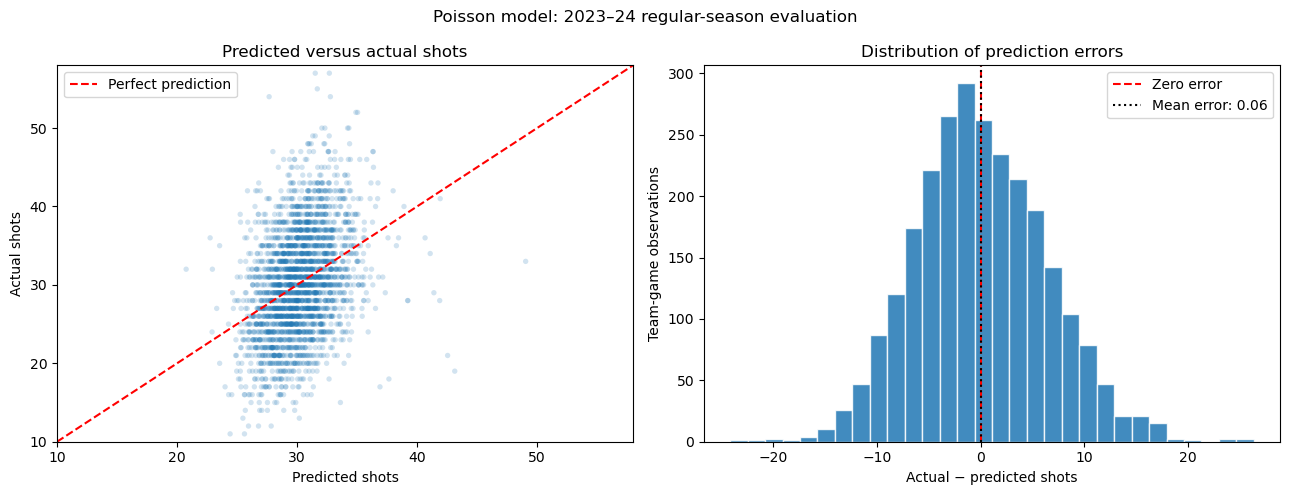

In [ ]:
# visualize the evaluation results
actual = evaluation_data["shots_on_goal"]
predicted = predictions["Poisson"]
errors = actual - predicted
print(f"Evaluation MAE: {errors.abs().mean():.3f} shots")
print(f"Mean error (actual - predicted): {errors.mean():.3f} shots")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
low = min(actual.min(), predicted.min()) - 1
high = max(actual.max(), predicted.max()) + 1
axes[0].scatter(predicted, actual, s=15, alpha=0.2, edgecolors="none")
axes[0].plot([low, high], [low, high], "--", color="red", label="Perfect prediction")
axes[0].set(title="Predicted versus actual shots", xlabel="Predicted shots",
            ylabel="Actual shots", xlim=(low, high), ylim=(low, high))
axes[0].legend()
axes[1].hist(errors, bins=30, edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", label="Zero error")
axes[1].axvline(errors.mean(), color="black", linestyle=":",
               label=f"Mean error: {errors.mean():.2f}")
axes[1].set(title="Distribution of prediction errors",
            xlabel="Actual − predicted shots", ylabel="Team-game observations")
axes[1].legend()
fig.suptitle("Poisson model: 2023–24 regular-season evaluation")
plt.tight_layout()
plt.show()

In [ ]:
# summarize the evaluation results by team
team_results = evaluation_data[["team_id", "team_name", "shots_on_goal"]].copy()
team_results["error"] = errors
team_results["absolute_error"] = errors.abs()
team_results["baseline_absolute_error"] = (
    actual - predictions["Baseline"]
).abs()
team_summary = team_results.groupby("team_name").agg(
    games=("error", "size"), mean_error=("error", "mean"),
    poisson_mae=("absolute_error", "mean"),
    baseline_mae=("baseline_absolute_error", "mean")
)
team_summary["improvement"] = team_summary["baseline_mae"] - team_summary["poisson_mae"]
display(team_summary.sort_values("improvement", ascending=False).round(3))
print(f"Teams improved: {team_summary['improvement'].gt(0).sum()} of {len(team_summary)}")

,games,mean_error,poisson_mae,baseline_mae,improvement
team_name,,,,,
Buffalo Sabres,80,1.031,5.717,6.246,0.529
Boston Bruins,81,-1.041,4.474,4.920,0.446
New York Rangers,81,1.186,5.102,5.512,0.410
Tampa Bay Lightning,81,-0.459,5.247,5.654,0.408
New York Islanders,81,0.433,4.650,5.057,0.408
Washington Capitals,81,-1.538,4.016,4.411,0.395
Carolina Hurricanes,81,0.660,5.058,5.427,0.369
Anaheim Ducks,81,-1.626,4.964,5.312,0.348
Vancouver Canucks,81,-0.454,5.110,5.454,0.344


Teams improved: 26 of 32


## 6. Findings and limitations

In the completed analysis, Poisson achieved an evaluation MAE of approximately **5.057 shots**, compared with **5.274** for the baseline and **5.091** for XGBoost. This is about a **4.1%** reduction in baseline error. Poisson was preferred for its interpretability and slightly lower validation error; its evaluation advantage over XGBoost was very small.

Overall mean error was approximately **+0.06 shots**, but individual predictions still missed by about five shots on average. Poisson improved on the baseline for **26 of 32 teams**. Low average bias for a team does not necessarily mean low MAE.

